# Visualizing protein sequence space as a hierarchical cluster plot


This notebook showcases how to analyze a protein family as series of hierarchical clusters.

**Required:** Run the [**run pipeline**](./run_pipeline.ipynb) notebook first (to end of homology method) to make sure the required outputs are present.    

## Step 1. Identify levels of interest and build layout
Can skip if done once and saved.  

In [52]:
import pickle
from proteinclustertools.layout.circle_layout_tools import Box2DLayout
import re
import os
import pandas as pd

Choose which analysis (homology, kmeans, hierarchical clustering) and which levels to use.   

First list the clustering files in the output folder (could also specify files in 'data_sets' manually):

In [ ]:
data_dir='../output/mmseqs_clustering/euk_chitin/' # could be mmseqs_clustering, kmeans, hierarchical_clustering

# alternative examples for other clustering outputs
# data_dir='../output/kmeans/flattened_10000/' # for kmeans
# data_dir='../output/hierarchical_clustering/' # for hierarchical clustering

data_sets={}
for f in os.listdir(data_dir):
    if f.endswith('.csv'):
        cutoff=f.split('_')[-1][:-4]
        data_sets[cutoff]=data_dir+f

# sort the data sets by cutoff
data_sets={k: data_sets[k] for k in sorted(data_sets, key=lambda x: float(x))}
cutoffs=list(data_sets.keys())
print(cutoffs)

['61.0', '111.0', '188.0', '285.0', '361.0']


Let's go with the 3 cut-offs corresponding to the 25, 50 and 75 percentiles of bitscores in the example set.

In [8]:
levels=['61.0', '111.0', '188.0', '285.0', '361.0']
levels

['61.0', '111.0', '188.0', '285.0', '361.0']

Load all the data sets (cluster definitions) into one file, with the cut-offs as the column headers.

**Note:** While sequence and cluster IDs are numbers, they are meant to be unique identifiers, and are thus treated as strings by the layout.

In [9]:
for cutoff in levels:
    clu=pd.read_csv(data_sets[cutoff], dtype=str)
    clu=clu.rename(columns={'cluster':cutoff})
    clu=clu.set_index('id')
    if cutoff==levels[0]:
        clust=clu
    else:
        clust=clust.join(clu, how='outer')
clust.reset_index(inplace=True)
clust.head()

,id,61.0,111.0,188.0,285.0,361.0
0,0,0,0,3,7,5
1,1,0,0,3,7,5
2,10,0,0,0,22,104
3,100,0,1,1,5,8
4,1000,0,0,0,6,7


### Build layout, can be skipped if using saved layout

Get a sense of how many clusters should be visualized.

In [10]:
test_cutoff=5 # minimum number of members in a cluster to be visualized

for level in levels:
    sizes=clust.groupby(level).size()
    print('level', level, ':', sum(sizes>=test_cutoff), 'clusters with at least', test_cutoff, 'members')

level 61.0 : 20 clusters with at least 5 members
level 111.0 : 45 clusters with at least 5 members
level 188.0 : 101 clusters with at least 5 members
level 285.0 : 207 clusters with at least 5 members
level 361.0 : 317 clusters with at least 5 members


Build the layout.

In [11]:
layout=Box2DLayout(
                    # Minimum required input
                    clust, levels, # which levels to include
                    minsize=test_cutoff, # minimum size of cluster to include
                    
                    # Broad layout options
                    pull=10, # how strongly to pull the clusters together when within the same parent, higher is stronger, usually 1 is fine
                    pull_base=False, radius_pad=5, # for the lowest level with no parents, whether they should be pulled, and how much space to separate them by
                    seed=1, # seed for random number generator, use the same seed to get the same layout

                    # Finetuning the physics simulation
                    cycle_scale=2000, max_cycles=100_000, # how many cycles to run per 50 clusters, up to max_cycles
                    time_step=1/20, velocity_iterations=16, position_iterations=6# finetuning, lower time step and hirher iterations gives nicer packing at the cost of speed
                )

Level 111.0, clusters: 45
preparing child clusters
Level 188.0, clusters: 101
preparing child clusters
Level 285.0, clusters: 207
preparing child clusters
Level 361.0, clusters: 317
preparing child clusters
starting pool
Level 61.0, clusters: 20


Save layout, especially if it took a while to make.

In [12]:
# save layout as binary object
with open('layouts/mmseqs_euk_chitin_61-111-188-285-361.pkl', 'wb') as f:
    pickle.dump(layout, f)

# save cluster data as well to avoid remaking, can skip if too large
clust.to_csv('layouts/mmseqs_euk_chitin_61-111-188-285-361.csv', index=False)

## 2. Plot hierarchical cluster plot

In [53]:
import proteinclustertools.visuals.circle_plot as cp
import proteinclustertools.visuals.annotate as an
import pickle
import pandas as pd
from matplotlib.colors import ListedColormap

Load layout for drawing.

In [54]:
with open('layouts/mmseqs_euk_chitin_61-111-188-285-361.pkl', 'rb') as f:
    layout=pickle.load(f)

Example of drawing just the layout, with no extra annotation.

In [55]:
plot, plot_data=cp.CirclePlot(layout, size=500)

#### Work on adding some extra information to the plot.  

**Important note:**
The headers for the fasta file were sanitized into numbers. To match the metadata, each sequence has to be mapped back to its original header.

**Reminder**
Load IDs (sequence or cluster) as strings.

In [56]:
# load header mapping
header_map=pd.read_csv('../output/euk_chitin_header_map.txt', dtype=str)
header_map.head()

,id,header
0,0,A0A010Q896|1of1
1,1,A0A010QB65|1of1
2,2,A0A010QMN9|1of2
3,3,A0A010R6C8|1of1
4,4,A0A010R807|1of3


Take a look at meta data table (downloaded from Uniprot in this case).

In [57]:
#annot_table=pd.read_csv('../../../20251020_interproscan/parsing/protein_GH18_fingerprints.tsv',sep='\t')
#annot_table=pd.read_csv('all_domains_annotated_deduplicated_cleaned_proteinfprint_withorg_taxidinfo.tsv',sep='\t')
annot_table = pd.read_csv('../data/alldomandGH18dom_merged_anno_dedupe.tsv',sep='\t')
taxa = pd.read_csv('all_domains_annotated_deduplicated_cleaned_proteinfprintGH18_taxonomy_euktaxid.tsv', sep='\t')
annot_table = annot_table.merge(taxa, left_on='protein_accession', right_on='Entry', how='left')
annot_table = annot_table.drop_duplicates(subset='fastaID', keep='first')
annot_table

/var/folders/k3/7_cndd213s1_cf9yqdgvytf80000gn/T/ipykernel_83944/2644311316.py:4: DtypeWarning: Columns (0: subspecies, 1: superphylum) have mixed types. Specify dtype option on import or set low_memory=False.
  taxa = pd.read_csv('all_domains_annotated_deduplicated_cleaned_proteinfprintGH18_taxonomy_euktaxid.tsv', sep='\t')


,protein_accession_x,sequence_md5,sequence_length,analysis,signature_accession,signature_description,start,end,score,status,...,TaxID_y,superkingdom_y,kingdom,phylum,class,order,family,genus,species,Taxid_y
0,A0A010Q896,245d59b18a934aa85a9966d5a6a31e62,407.0,PFAM,PF00704,Glycosyl hydrolases family 18,36.0,372.0,233.700000,T,...,1445577.0,NaN,Fungi,Ascomycota,Sordariomycetes,Glomerellales,Glomerellaceae,Colletotrichum,Colletotrichum fioriniae,1445577.0
1,A0A010QB65,7d722e83f848e9debdeb1b6d9890fb5b,445.0,PFAM,PF00704,Glycosyl hydrolases family 18,34.0,427.0,251.300000,T,...,1445577.0,NaN,Fungi,Ascomycota,Sordariomycetes,Glomerellales,Glomerellaceae,Colletotrichum,Colletotrichum fioriniae,1445577.0
2,A0A010QB65,7d722e83f848e9debdeb1b6d9890fb5b,445.0,PFAM,PF00187,Chitin recognition protein,321.0,354.0,34.900000,T,...,1445577.0,NaN,Fungi,Ascomycota,Sordariomycetes,Glomerellales,Glomerellaceae,Colletotrichum,Colletotrichum fioriniae,1445577.0
3,A0A010QGA4,1f21f31d300a8c1894b03929e9348875,359.0,PFAM,PF00704,Glycosyl hydrolases family 18,24.0,336.0,221.800000,T,...,1445577.0,NaN,Fungi,Ascomycota,Sordariomycetes,Glomerellales,Glomerellaceae,Colletotrichum,Colletotrichum fioriniae,1445577.0
4,A0A010QHE0,61220b600d01c3e24bf378f7b18bba38,929.0,PFAM,PF00704,Glycosyl hydrolases family 18,7.0,293.0,199.800000,T,...,1445577.0,NaN,Fungi,Ascomycota,Sordariomycetes,Glomerellales,Glomerellaceae,Colletotrichum,Colletotrichum fioriniae,1445577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87904,X6LUP5,eb144bee16bd5eb570e53c12ebf908c4,225.0,PFAM,PF00704,Glycosyl hydrolases family 18,4.0,197.0,53.900000,T,...,46433.0,NaN,NaN,Foraminifera,NaN,NaN,Reticulomyxidae,Reticulomyxa,NaN,46433.0
87905,X6MGQ6,23eafa815de09d8b64a7915ef70697a8,257.0,PFAM,PF00704,Glycosyl hydrolases family 18,66.0,248.0,36.700000,T,...,46433.0,NaN,NaN,Foraminifera,NaN,NaN,Reticulomyxidae,Reticulomyxa,NaN,46433.0
87906,X6MH14,5995b182848e1c5af818060ae006c311,142.0,PFAM,PF00704,Glycosyl hydrolases family 18,20.0,133.0,36.600000,T,...,46433.0,NaN,NaN,Foraminifera,NaN,NaN,Reticulomyxidae,Reticulomyxa,NaN,46433.0
87907,X6NNN9,b1a6c3293415743a48918826c73d23ae,246.0,PFAM,PF00704,Glycosyl hydrolases family 18,73.0,245.0,37.700000,T,...,46433.0,NaN,NaN,Foraminifera,NaN,NaN,Reticulomyxidae,Reticulomyxa,NaN,46433.0


In [21]:
from Bio import Entrez
import pandas as pd
from http.client import IncompleteRead
from urllib.error import HTTPError
import time

Entrez.email = "u6083238@anu.edu.au"
Entrez.api_key = "5970aa2ad358b4415a8165e5f391291dd308"  # get one free at ncbi.nlm.nih.gov/account/settings/

taxid_list = list(set(annot_table['Organism (ID)'].to_list()))
batch_size = 200  # smaller batches = less to lose per failure, less likely to trigger drops

def fetch_batch_with_retry(taxid_batch, max_retries=5):
    for attempt in range(max_retries):
        try:
            handle = Entrez.efetch(db="taxonomy", id=taxid_batch, retmode="xml")
            records = Entrez.read(handle, validate=False)
            handle.close()
            return records
        except (IncompleteRead, HTTPError, ConnectionError) as e:
            wait = 2 ** attempt  # exponential backoff: 1, 2, 4, 8, 16s
            print(f"Attempt {attempt+1} failed ({e}); retrying in {wait}s...")
            time.sleep(wait)
    print(f"Giving up on batch after {max_retries} attempts: {taxid_batch[:5]}...")
    return []

taxonomy_data = []
failed_batches = []

for i in range(0, len(taxid_list), batch_size):
    taxid_batch = taxid_list[i:i+batch_size]
    records = fetch_batch_with_retry(taxid_batch)
    if not records:
        failed_batches.append(taxid_batch)
        continue
    for record in records:
        try:
            taxonomy_dict = {"TaxID": record["TaxId"]}
            for data in record["LineageEx"]:
                taxonomy_dict[data["Rank"]] = data["ScientificName"]
            taxonomy_data.append(taxonomy_dict)
        except KeyError:
            print(f"No lineage information found for TaxID {record.get('TaxId', '?')}")
    time.sleep(0.15)  # ~6-7 req/sec, safely under the 10/sec API-key limit

if failed_batches:
    print(f"{len(failed_batches)} batches failed entirely — inspect `failed_batches` and rerun those.")

taxa_df1 = pd.DataFrame(taxonomy_data)
taxa_df1 = taxa_df1.reindex(columns=['TaxID', 'superkingdom', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species'])
taxa_df1['Taxid'] = taxa_df1['TaxID'].astype(str)

In [8]:
annot_table.columns

Index(['protein_accession_x', 'sequence_md5', 'sequence_length', 'analysis',
       'signature_accession', 'signature_description', 'start', 'end', 'score',
       'status', 'date', 'interpro_accession', 'interpro_description',
       'go_annotations', 'pathway_annotations', 'fasta_description',
       'sequence', 'sequence_len_fasta', 'is_chitinase_related',
       'matched_terms', 'start_num', 'end_num', 'score_num', 'span',
       'priority_rank', 'sig_freq_global', 'Total_num_GH18domains',
       'GH18domain_num', 'GH18sequence', 'fastaID', 'GH18_ID_x',
       'protein_accession_y', 'signature_accession_fingerprint',
       'signature_spans', 'sequence_length_total', 'GH18_ID_y',
       'signature_accession_fingerprint_GH18replaced', 'num_of_domains',
       'no_GH18_domains', 'Entry', 'Organism', 'Organism (ID)', 'Reviewed',
       'Protein names', 'Taxonomic lineage', 'class_x', 'family_x', 'genus_x',
       'kingdom_x', 'order_x', 'phylum_x', 'species_x', 'subclass',
       'sub

In [24]:
#make Taxid column in fastadescp a string
annot_table['Organism (ID)'] = annot_table['Organism (ID)'].astype(str)
annot_table = annot_table.merge(taxa_df1, right_on='Taxid', left_on='Organism (ID)', how='left')
annot_table = annot_table.drop_duplicates(subset='Entry', keep='first')
annot_table

,protein_accession,signature_accession_fingerprint,signature_spans,sequence_length_total,GH18_ID,signature_accession_fingerprint_GH18replaced,num_of_domains,no_GH18_domains,Entry,Organism,...,TaxID_y,superkingdom_y,kingdom,phylum,class,order,family,genus,species,Taxid_y
0,A0A010Q896,PF00704,PF00704[36-372],407,PF00704,GH18,1,1,A0A010Q896,Colletotrichum fioriniae PJ7,...,1445577,NaN,Fungi,Ascomycota,Sordariomycetes,Glomerellales,Glomerellaceae,Colletotrichum,Colletotrichum fioriniae,1445577
1,A0A010QB65,PF00704 PF00187,PF00704[34-427] PF00187[321-354],445,PF00704,GH18 PF00187,2,1,A0A010QB65,Colletotrichum fioriniae PJ7,...,1445577,NaN,Fungi,Ascomycota,Sordariomycetes,Glomerellales,Glomerellaceae,Colletotrichum,Colletotrichum fioriniae,1445577
2,A0A010QGA4,PF00704,PF00704[24-336],359,PF00704,GH18,1,1,A0A010QGA4,Colletotrichum fioriniae PJ7,...,1445577,NaN,Fungi,Ascomycota,Sordariomycetes,Glomerellales,Glomerellaceae,Colletotrichum,Colletotrichum fioriniae,1445577
3,A0A010QHE0,PF00704,PF00704[7-293],929,PF00704,GH18,1,1,A0A010QHE0,Colletotrichum fioriniae PJ7,...,1445577,NaN,Fungi,Ascomycota,Sordariomycetes,Glomerellales,Glomerellaceae,Colletotrichum,Colletotrichum fioriniae,1445577
4,A0A010QMN9,G3DSA:3.30.60.10 PF00704 PS51257 PF00187,G3DSA:3.30.60.10[61-101] PF00704[110-447] PS51...,1211,G3DSA:3.30.60.10 PF00704,GH18 GH18 PS51257 PF00187,4,2,A0A010QMN9,Colletotrichum fioriniae PJ7,...,1445577,NaN,Fungi,Ascomycota,Sordariomycetes,Glomerellales,Glomerellaceae,Colletotrichum,Colletotrichum fioriniae,1445577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46479,X6LUP5,PF00704,PF00704[4-197],225,PF00704,GH18,1,1,X6LUP5,Reticulomyxa filosa,...,46433,NaN,NaN,Foraminifera,NaN,NaN,Reticulomyxidae,Reticulomyxa,NaN,46433
46480,X6MGQ6,PF00704,PF00704[66-248],257,PF00704,GH18,1,1,X6MGQ6,Reticulomyxa filosa,...,46433,NaN,NaN,Foraminifera,NaN,NaN,Reticulomyxidae,Reticulomyxa,NaN,46433
46481,X6MH14,PF00704,PF00704[20-133],142,PF00704,GH18,1,1,X6MH14,Reticulomyxa filosa,...,46433,NaN,NaN,Foraminifera,NaN,NaN,Reticulomyxidae,Reticulomyxa,NaN,46433
46482,X6NNN9,PF00704,PF00704[73-245],246,PF00704,GH18,1,1,X6NNN9,Reticulomyxa filosa,...,46433,NaN,NaN,Foraminifera,NaN,NaN,Reticulomyxidae,Reticulomyxa,NaN,46433


In [ ]:
annot_table.to_csv('all_domains_annotated_deduplicated_cleaned_proteinfprintGH18_taxonomy_euktaxid.tsv', sep='\t', index=False)

In [67]:
annot_table = pd.read_csv('all_domains_annotated_deduplicated_cleaned_proteinfprintGH18_taxonomy_euktaxid.tsv', sep='\t')

/var/folders/k3/7_cndd213s1_cf9yqdgvytf80000gn/T/ipykernel_83944/85348567.py:1: DtypeWarning: Columns (0: subspecies, 1: superphylum) have mixed types. Specify dtype option on import or set low_memory=False.
  annot_table = pd.read_csv('all_domains_annotated_deduplicated_cleaned_proteinfprintGH18_taxonomy_euktaxid.tsv', sep='\t')


Headers in the header_map have to be converted to be same in 'Entry' in the annot_table.

In [58]:
header_map['fastaID']=header_map['header']#.apply(lambda x: x.split('|')[0])
header_map['Uniprot_Accessions']=header_map['header'].apply(lambda x: x.split('|')[0])
header_map.head()

,id,header,fastaID,Uniprot_Accessions
0,0,A0A010Q896|1of1,A0A010Q896|1of1,A0A010Q896
1,1,A0A010QB65|1of1,A0A010QB65|1of1,A0A010QB65
2,2,A0A010QMN9|1of2,A0A010QMN9|1of2,A0A010QMN9
3,3,A0A010R6C8|1of1,A0A010R6C8|1of1,A0A010R6C8
4,4,A0A010R807|1of3,A0A010R807|1of3,A0A010R807


Load in the cluster definitions and apply the header mapping.

In [91]:
clusters=pd.read_csv('layouts/mmseqs_euk_chitin_61-111-188-285-361.csv', dtype=str)
levels=clusters.columns[1:]
clusters.head()

,id,61.0,111.0,188.0,285.0,361.0
0,0,0,0,3,7,5
1,1,0,0,3,7,5
2,10,0,0,0,22,104
3,100,0,1,1,5,8
4,1000,0,0,0,6,7


In [92]:
clusters=clusters.merge(header_map[['fastaID','id']], on='id')
clusters=clusters.merge(header_map[['Uniprot_Accessions','id']], on='id')
clusters.head()

,id,61.0,111.0,188.0,285.0,361.0,fastaID,Uniprot_Accessions
0,0,0,0,3,7,5,A0A010Q896|1of1,A0A010Q896
1,1,0,0,3,7,5,A0A010QB65|1of1,A0A010QB65
2,10,0,0,0,22,104,A0A016S9Z0|1of1,A0A016S9Z0
3,100,0,1,1,5,8,A0A060SC99|1of1,A0A060SC99
4,1000,0,0,0,6,7,A0A0D2N077|1of1,A0A0D2N077


In [93]:
clusters.to_csv('euk_clusters.csv')

In [65]:
ciddf = pd.read_csv('euk_CID_hmmsearch.csv')
ciddf.columns

Index(['target_name', 'target_accession', 'tlen', 'query_name',
       'query_accession', 'qlen', 'seq_evalue', 'seq_score', 'seq_bias',
       'dom_num', 'dom_total', 'dom_c_evalue', 'dom_i_evalue', 'dom_score',
       'dom_bias', 'hmm_from', 'hmm_to', 'ali_from', 'ali_to', 'env_from',
       'env_to', 'acc', 'description', 'Uniprot_Accessions'],
      dtype='str')

In [74]:
promiscuitydf

,Unnamed: 0,protein_accession,signature_accession_fingerprint,signature_spans,sequence_length_total,GH18_ID,signature_accession_fingerprint_GH18replaced,num_of_domains,no_GH18_domains,Entry,...,superclass,superfamily,superorder,superphylum,clade_ordered,no rank_ordered,non_GH18_fingerprint,GH18_fingerprint,promiscuous,housekeeper
0,0,A0A010Q896,PF00704,PF00704[36-372],407,PF00704,GH18,1,1,A0A010Q896,...,NaN,NaN,NaN,NaN,Opisthokonta; saccharomyceta; leotiomyceta; so...,cellular organisms; Colletotrichum acutatum sp...,NaN,GH18,NaN,NaN
1,1,A0A010QB65,PF00704 PF00187,PF00704[34-427] PF00187[321-354],445,PF00704,GH18 PF00187,2,1,A0A010QB65,...,NaN,NaN,NaN,NaN,Opisthokonta; saccharomyceta; leotiomyceta; so...,cellular organisms; Colletotrichum acutatum sp...,PF00187,GH18 PF00187,NaN,T
2,2,A0A010QGA4,PF00704,PF00704[24-336],359,PF00704,GH18,1,1,A0A010QGA4,...,NaN,NaN,NaN,NaN,Opisthokonta; saccharomyceta; leotiomyceta; so...,cellular organisms; Colletotrichum acutatum sp...,NaN,GH18,NaN,NaN
3,3,A0A010QHE0,PF00704,PF00704[7-293],929,PF00704,GH18,1,1,A0A010QHE0,...,NaN,NaN,NaN,NaN,Opisthokonta; saccharomyceta; leotiomyceta; so...,cellular organisms; Colletotrichum acutatum sp...,NaN,GH18,NaN,NaN
4,4,A0A010QMN9,G3DSA:3.30.60.10 PF00704 PS51257 PF00187,G3DSA:3.30.60.10[61-101] PF00704[110-447] PS51...,1211,G3DSA:3.30.60.10 PF00704,GH18 GH18 PS51257 PF00187,4,2,A0A010QMN9,...,NaN,NaN,NaN,NaN,Opisthokonta; saccharomyceta; leotiomyceta; so...,cellular organisms; Colletotrichum acutatum sp...,PS51257 PF00187,GH18 GH18 PS51257 PF00187,NaN,T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46479,46479,X6LUP5,PF00704,PF00704[4-197],225,PF00704,GH18,1,1,X6LUP5,...,NaN,NaN,NaN,NaN,Sar; Rhizaria; Retaria; Monothalamids,cellular organisms,NaN,GH18,NaN,NaN
46480,46480,X6MGQ6,PF00704,PF00704[66-248],257,PF00704,GH18,1,1,X6MGQ6,...,NaN,NaN,NaN,NaN,Sar; Rhizaria; Retaria; Monothalamids,cellular organisms,NaN,GH18,NaN,NaN
46481,46481,X6MH14,PF00704,PF00704[20-133],142,PF00704,GH18,1,1,X6MH14,...,NaN,NaN,NaN,NaN,Sar; Rhizaria; Retaria; Monothalamids,cellular organisms,NaN,GH18,NaN,NaN
46482,46482,X6NNN9,PF00704,PF00704[73-245],246,PF00704,GH18,1,1,X6NNN9,...,NaN,NaN,NaN,NaN,Sar; Rhizaria; Retaria; Monothalamids,cellular organisms,NaN,GH18,NaN,NaN


In [76]:
promiscuitydf = pd.read_csv('../data/all_domains_annotated_deduplicated_cleaned_proteinfprintGH18_taxonomy_promandHK.csv')
prom_map_df = promiscuitydf[promiscuitydf["promiscuous"].notna()][["protein_accession", "promiscuous"]].copy()
hk_map_df = promiscuitydf[promiscuitydf["housekeeper"].notna()][["protein_accession", "housekeeper"]].copy()



/var/folders/k3/7_cndd213s1_cf9yqdgvytf80000gn/T/ipykernel_83944/1792869086.py:1: DtypeWarning: Columns (0: subspecies, 1: superphylum) have mixed types. Specify dtype option on import or set low_memory=False.
  promiscuitydf = pd.read_csv('../data/all_domains_annotated_deduplicated_cleaned_proteinfprintGH18_taxonomy_promandHK.csv')


#### The two tables now have matching ID columns, we can apply annotations.

In [82]:
cid = an.AnnotateClusters(clusters,[levels[-1]], ciddf, 'query_name','Uniprot_Accessions', 'Uniprot_Accessions')
phylum = an.AnnotateClusters(clusters, [levels[-1]], annot_table,'phylum','Uniprot_Accessions','protein_accession')
classeuk = an.AnnotateClusters(clusters, [levels[-1]], annot_table,'class','Uniprot_Accessions','protein_accession')
kingdomtop = an.AnnotateClusters(clusters, [levels[-1]], annot_table,'kingdom','Uniprot_Accessions','protein_accession')
kingdom = an.AnnotateClusters(clusters, levels, annot_table,'kingdom','Uniprot_Accessions','protein_accession')
prom = an.AnnotateClusters(clusters, [levels[-1]], prom_map_df,'promiscuous','Uniprot_Accessions','protein_accession')
hk = an.AnnotateClusters(clusters, [levels[-1]], hk_map_df,'housekeeper','Uniprot_Accessions','protein_accession')
promfull = an.AnnotateClusters(clusters, [levels[-1]], promiscuitydf,'promiscuous','Uniprot_Accessions','protein_accession')
hkfull = an.AnnotateClusters(clusters, [levels[-1]], promiscuitydf,'housekeeper','Uniprot_Accessions','protein_accession')

In [14]:
#ensure heterogeneity_simpson values are strings and remove any Nan in annot_table df
#annot_table['heterogeneity_simpson'] = annot_table['heterogeneity_simpson'].astype(float)
#annot_table = annot_table.dropna(subset=['heterogeneity_simpson'])
IPscan_Simps=an.AnnotateClusters(clusters, [levels[-1]], annot_table, 'heterogeneity_simpson', 'fastaID', 'fastaID')



KeyError: 'heterogeneity_simpson'

In [37]:
annot_table.columns

Index(['protein_accession_x', 'sequence_md5', 'sequence_length', 'analysis',
       'signature_accession', 'signature_description', 'start', 'end', 'score',
       'status', 'date', 'interpro_accession', 'interpro_description',
       'go_annotations', 'pathway_annotations', 'fasta_description',
       'sequence', 'sequence_len_fasta', 'is_chitinase_related',
       'matched_terms', 'start_num', 'end_num', 'score_num', 'span',
       'priority_rank', 'sig_freq_global', 'Total_num_GH18domains',
       'GH18domain_num', 'GH18sequence', 'fastaID', 'GH18_ID_x',
       'protein_accession_y', 'signature_accession_fingerprint',
       'signature_spans', 'sequence_length_total', 'GH18_ID_y',
       'signature_accession_fingerprint_GH18replaced', 'num_of_domains',
       'no_GH18_domains', 'Entry', 'Organism', 'Organism (ID)', 'Reviewed',
       'Protein names', 'Taxonomic lineage', 'class_x', 'family_x', 'genus_x',
       'kingdom_x', 'order_x', 'phylum_x', 'species_x', 'subclass',
       'sub

In [31]:
#IPaux_gh18aux=an.AnnotateClusters(clusters, levels, annot_table, 'GH18_fingerprint', 'protein_accession', 'protein_accession')
IPaux_uneditedaux=an.AnnotateClusters(clusters, levels, annot_table, 'signature_accession_fingerprint', 'fastaID', 'fastaID')
IPscan_GH18normfprint=an.AnnotateClusters(clusters, levels, annot_table, 'signature_accession_fingerprint_GH18replaced', 'fastaID', 'fastaID')
IPscan_GH18fprint=an.AnnotateClusters(clusters, levels, annot_table, 'GH18_ID_x', 'fastaID', 'fastaID')
IPscan_nodomains=an.AnnotateClusters(clusters, levels, annot_table, 'num_of_domains', 'fastaID', 'fastaID')
IPscan_noGH18domains=an.AnnotateClusters(clusters, levels, annot_table, 'no_GH18_domains', 'fastaID', 'fastaID')
IPscan_phylum=an.AnnotateClusters(clusters, [levels[-1]], annot_table, 'phylum', 'fastaID', 'fastaID')
IPscan_class=an.AnnotateClusters(clusters, [levels[-1]], annot_table, 'class', 'fastaID', 'fastaID')
kingdom = an.AnnotateClusters(clusters, [levels[-1]], annot_table, 'kingdom', 'fastaID', 'fastaID')


KeyError: "['fastaID'] not in index"

In [32]:
# categorical values
phylums=an.AnnotateClusters(clusters, levels, annot_table, 'phylum', 'Entry|domains|HMM|org', 'Entry|domains|HMM|org')
# numeric values
lengths=an.AnnotateClusters(clusters, levels, annot_table, 'Length', 'Entry|domains|HMM|org', 'Entry|domains|HMM|org', numeric_func='mean')
length_sd=an.AnnotateClusters(clusters, levels, annot_table, 'Length', 'Entry|domains|HMM|org', 'Entry|domains|HMM|org', numeric_func='std')
pfams=an.AnnotateClusters(clusters, levels, annot_table, 'Pfam', 'Entry|domains|HMM|org', 'Entry|domains|HMM|org')
pfamscan=an.AnnotateClusters(clusters, levels, annot_table, 'Pfamscan', 'Entry|domains|HMM|org', 'Entry|domains|HMM|org')
reviewed=an.AnnotateClusters(clusters, [levels[-1]], annot_table, "Reviewed", "Entry|domains|HMM|org", "Entry|domains|HMM|org")
#reps = an.AnnotateClusters(clusters, levels, annot_table, 'Representative', 'Entry|domains|HMM|org', 'Entry|domains|HMM|org')

totaldom=an.AnnotateClusters(clusters, levels, annot_table, 'Total_domains', 'Entry|domains|HMM|org', 'Entry|domains|HMM|org', numeric_func='mean')
no_doms=an.AnnotateClusters(clusters, levels, annot_table, 'no_pfamscan_domains', 'Entry|domains|HMM|org', 'Entry|domains|HMM|org', numeric_func='mean')


KeyError: "['Entry|domains|HMM|org'] not in index"

In [91]:
is_reviewed=annot_table['Reviewed']=='reviewed'
reviewed_only=clusters[clusters['Entry|domains|HMM|org'].isin(annot_table[is_reviewed]['Entry|domains|HMM|org'])]
reviewed=an.AnnotateClusters(reviewed_only, [levels[-1]], annot_table, "Reviewed", "Entry|domains|HMM|org", "Entry|domains|HMM|org")
reviewed_colors=an.ColorAnnot(reviewed, cmap=ListedColormap(['red']), saturation=.7)

In [77]:
#what type of data is in column Pfamscan of annot_table
annot_table['Pfamscan'].value_counts()

Pfamscan
PF00704                            16460
PF01476 PF01476 PF00704             2048
PF02018 PF00041 PF00704             1617
PF00553 PF00041 PF00704             1110
PF07833 PF00704                      985
                                   ...  
PF00704 PF22544                        1
PF00150 PF05345 PF00704 PF17957        1
PF00704 PF13517 PF13517                1
PF18911 PF00801 PF00704                1
PF18911 PF18911 PF02839 PF18911        1
Name: count, Length: 915, dtype: int64

In [187]:
import pandas as pd

# 1. Read your list of “unpromiscuous” PF codes
with open("../data/common_nonprom.txt") as f:
    pf_codes = {line.strip() for line in f if line.strip()}

# 2. Load your annot_table (tsv) into a DataFrame
#annot_table = pd.read_csv("annot_table.tsv", sep="\t")
#ensure Pfamscan column is string
#annot_table = pd.read_csv("annot_table_IPR001223_bact_arch_jackseq_annot_HMMseqs_and_NOhmmexplodeddomains_ANNOT_pfamscan.csv", sep=",")
# Convert Pfamscan column to string type
annot_table["Pfamscan"] = annot_table["Pfamscan"].astype(str)

# 3. Define a boolean mask: does any PF in Pfamscan match one of our pf_codes?
mask = (
    annot_table["Pfamscan"]
    .str.split()                                        # split on whitespace
    .apply(lambda codes: bool(set(codes) & pf_codes))  # intersection non‐empty?
)

# 4. Build com_unprom by selecting the matching rows
com_unprom = annot_table.loc[mask, ["Entry|domains|HMM|org"]].copy()

# 5. Add your new column
com_unprom["common_unprom"] = "CU"

annot_table = annot_table.merge(com_unprom, on="Entry|domains|HMM|org", how="left")
# (Optional) write out to TSV
com_unprom#.to_csv("com_unprom.tsv", sep="\t", index=False)


,Entry|domains|HMM|org,common_unprom
0,A0A1H5YSH1|1of3|HMM|Paenibacillus_sp._UNC499MF,CU
1,A0A1H5YSH1|2of3|HMM|Paenibacillus_sp._UNC499MF,CU
2,A0A1H5YSH1|3of3|HMM|Paenibacillus_sp._UNC499MF,CU
3,F5LPK1|1of3|HMM|Paenibacillus_sp._HGF7,CU
4,F5LPK1|2of3|HMM|Paenibacillus_sp._HGF7,CU
...,...,...
40306,V9HGV1|1of1|noHMM|Clostridium_sp._7_2_43FAA,CU
40308,A0A2Z2NGA0|1of1|noHMM|Thermococcus_chitonophagus,CU
40309,A0A3N6MAZ1|1of1|noHMM|Natrarchaeobius_chitiniv...,CU
40311,M0IGJ5|1of1|noHMM|Haloferax_mucosum_ATCC_BAA-1512,CU


In [291]:
# 1. pull out the list of matching entries
cu_entries = com_unprom["Entry|domains|HMM|org"].tolist()

# 2. boolean‐index clusters using that list
reviewed_only = clusters[
    clusters["Entry|domains|HMM|org"].isin(cu_entries)
]

# 3. now annotate and color as before
com_unprom_annot = an.AnnotateClusters(
    reviewed_only,
    [levels[-1]],
    #levels,
    annot_table,
    "common_unprom",
    "Entry|domains|HMM|org",
    "Entry|domains|HMM|org"
)
com_unprom_annot_colors = an.ColorAnnot(
    com_unprom_annot,
    cmap=ListedColormap(['#1E9958']),  # use a single color for unpromiscuous
    saturation=0.7
)


In [189]:
import pandas as pd

# 1. Read your list of “unpromiscuous” PF codes
with open("../data/common_prom.txt") as f:
    pf_codes = {line.strip() for line in f if line.strip()}

# 2. Load your annot_table (tsv) into a DataFrame
#annot_table = pd.read_csv("annot_table.tsv", sep="\t")
#ensure Pfamscan column is string
#annot_table = pd.read_csv("annot_table_IPR001223_bact_arch_jackseq_annot_HMMseqs_and_NOhmmexplodeddomains_ANNOT_pfamscan.csv", sep=",")
# Convert Pfamscan column to string type
annot_table["Pfamscan"] = annot_table["Pfamscan"].astype(str)

# 3. Define a boolean mask: does any PF in Pfamscan match one of our pf_codes?
mask = (
    annot_table["Pfamscan"]
    .str.split()                                        # split on whitespace
    .apply(lambda codes: bool(set(codes) & pf_codes))  # intersection non‐empty?
)

# 4. Build com_unprom by selecting the matching rows
com_prom = annot_table.loc[mask, ["Entry|domains|HMM|org"]].copy()

# 5. Add your new column
com_prom["common_prom"] = "CP"
annot_table = annot_table.merge(com_prom, on="Entry|domains|HMM|org", how="left")
# (Optional) write out to TSV
com_prom#.to_csv("com_unprom.tsv", sep="\t", index=False)


,Entry|domains|HMM|org,common_prom
19,A0AAU9D871|1of2|HMM|Haliovirga_abyssi,CP
20,A0AAU9D871|2of2|HMM|Haliovirga_abyssi,CP
37,A0A6N6RP54|1of3|HMM|Aliivibrio_finisterrensis,CP
38,A0A6N6RP54|2of3|HMM|Aliivibrio_finisterrensis,CP
39,A0A6N6RP54|3of3|HMM|Aliivibrio_finisterrensis,CP
...,...,...
39891,A0A2U9TB29|1of1|noHMM|Marilutibacter_maris,CP
39957,A0A4Y8Q8T1|1of1|noHMM|Paenibacillus_athensensis,CP
39968,A0A543DB60|1of1|noHMM|Pseudoxanthomonas_sp._3HH-4,CP
40019,A0A6J4UT33|1of1|noHMM|uncultured_Truepera_sp,CP


In [190]:
# 1. pull out the list of matching entries
cu_entries = com_prom["Entry|domains|HMM|org"].tolist()

# 2. boolean‐index clusters using that list
reviewed_only = clusters[
    clusters["Entry|domains|HMM|org"].isin(cu_entries)
]

# 3. now annotate and color as before
com_prom_annot = an.AnnotateClusters(
    reviewed_only,
    [levels[-1]],
    #levels,
    annot_table,
    "common_prom",
    "Entry|domains|HMM|org",
    "Entry|domains|HMM|org"
)
com_prom_annot_colors = an.ColorAnnot(
    com_prom_annot,
    cmap=ListedColormap(['blue']),
    saturation=0.7
)


In [191]:
import pandas as pd

# 1. Read your list of “unpromiscuous” PF codes
with open("../data/uncommon_prom.txt") as f:
    pf_codes = {line.strip() for line in f if line.strip()}

# 2. Load your annot_table (tsv) into a DataFrame
#annot_table = pd.read_csv("annot_table.tsv", sep="\t")
#ensure Pfamscan column is string
#annot_table = pd.read_csv("annot_table_IPR001223_bact_arch_jackseq_annot_HMMseqs_and_NOhmmexplodeddomains_ANNOT_pfamscan.csv", sep=",")
# Convert Pfamscan column to string type
annot_table["Pfamscan"] = annot_table["Pfamscan"].astype(str)

# 3. Define a boolean mask: does any PF in Pfamscan match one of our pf_codes?
mask = (
    annot_table["Pfamscan"]
    .str.split()                                        # split on whitespace
    .apply(lambda codes: bool(set(codes) & pf_codes))  # intersection non‐empty?
)

# 4. Build com_unprom by selecting the matching rows
uncom_prom = annot_table.loc[mask, ["Entry|domains|HMM|org"]].copy()

# 5. Add your new column
uncom_prom["uncommon_prom"] = "UP"

# (Optional) write out to TSV
uncom_prom#.to_csv("com_unprom.tsv", sep="\t", index=False)


,Entry|domains|HMM|org,uncommon_prom
299,A0A4U7JHD7|1of1|HMM|Ruminiclostridium_herbifer...,UP
1164,A0A9C8L7B2|1of1|HMM|Chloroflexota_bacterium,UP
1231,A0A2E0AK67|1of2|HMM|Cyanobium_sp._NAT70,UP
1232,A0A2E0AK67|2of2|HMM|Cyanobium_sp._NAT70,UP
1406,A0A552ET34|1of1|HMM|Microcystis_aeruginosa_Ma_...,UP
7028,A0A656HFI7|1of1|HMM|Thiothrix_nivea,UP
13229,A0A5C5Z6E2|1of1|HMM|Novipirellula_herctigrandis,UP
16275,A0A933YPS3|1of1|HMM|Ignavibacteriota_bacterium,UP
23327,A0A922ZDN2|1of1|HMM|Chlorobiaceae_bacterium,UP
24861,A0A7V4HGF8|1of1|HMM|Lentisphaerota_bacterium,UP


In [192]:
# 1. pull out the list of matching entries
cu_entries = uncom_prom["Entry|domains|HMM|org"].tolist()

# 2. boolean‐index clusters using that list
reviewed_only = clusters[
    clusters["Entry|domains|HMM|org"].isin(cu_entries)
]

# 3. now annotate and color as before
uncom_prom_annot = an.AnnotateClusters(
    reviewed_only,
    [levels[-1]],
    #levels,
    annot_table,
    "uncommon_prom",
    "Entry|domains|HMM|org",
    "Entry|domains|HMM|org"
)
uncom_prom_annot_colors = an.ColorAnnot(
    uncom_prom_annot,
    cmap=ListedColormap(['green']),
    saturation=0.7
)


In [117]:

annot_table = annot_table.merge(uncom_prom, on='Entry|domains|HMM|org', how='left')

In [ ]:
#is_reviewed=annot_table['Reviewed']=='reviewed'
reviewed_only=clusters[clusters['Entry|domains|HMM|org'].isin(annot_table[com_unprom]['Entry|domains|HMM|org'])]
reviewed=an.AnnotateClusters(reviewed_only, [levels[-1]], annot_table, "common_prom", "Entry|domains|HMM|org", "Entry|domains|HMM|org")
reviewed_colors=an.ColorAnnot(reviewed, cmap=ListedColormap(['red']), saturation=.7)

In [ ]:
# 1. pull out the list of matching entries
cu_entries = uncom_prom["Entry|domains|HMM|org"].tolist()

# 2. boolean‐index clusters using that list
reviewed_only = clusters[
    clusters["Entry|domains|HMM|org"].isin(cu_entries)
]

# 3. now annotate and color as before
uncom_prom_annot = an.AnnotateClusters(
    reviewed_only,
    [levels[-1]],
    #levels,
    annot_table,
    "uncommon_prom",
    "Entry|domains|HMM|org",
    "Entry|domains|HMM|org"
)
uncom_prom_annot_colors = an.ColorAnnot(
    reviewed,
    cmap=ListedColormap(['green']),
    saturation=0.7
)


In [257]:
import pandas as pd
import numpy as np

# 1. Load your promiscuity mapping
prom_df = pd.read_csv("../data/promiscuity copy.txt", dtype=str)  # file has columns Pfam,promiscuity
# create a dict for fast lookup
prom_map = dict(zip(prom_df["Pfam"], prom_df["promiscuos"]))

# 2. Load your annot_table
#annot_table = pd.read_csv("annot_table.tsv", sep="\t", dtype=str)

# 3. Define a function to collect all promiscuity labels for one row
def collect_promiscuity(pfam_cell):
    if pd.isna(pfam_cell):
        return np.nan
    codes = pfam_cell.split()  # assumes whitespace‐separated PF codes
    labs = [prom_map[c] for c in codes if c in prom_map]
    # remove duplicates but keep order
    seen = set()
    uniq = []
    for l in labs:
        if l not in seen:
            seen.add(l)
            uniq.append(l)
    return ";".join(uniq) if uniq else np.nan

# 4. Apply it to make a new column
annot_table["promiscuos"] = annot_table["Pfamscan"].apply(collect_promiscuity)

# 5. (Optional) Save out
#annot_table#.to_csv("annot_table_with_promiscuity.tsv", sep="\t", index=False)


In [238]:
annot_table .columns

Index(['Entry', 'Domain_number', 'Start', 'End', 'Score', 'Domain_sequence',
       'Total_domains', 'Reviewed', 'Entry Name', 'Protein names', 'Organism',
       'Protein families', 'Gene Ontology IDs', 'Gene Ontology (GO)', 'CDD',
       'Pfam', 'InterPro', 'EC number', 'Domain [CC]', 'Domain [FT]', 'Region',
       'Organism (ID)', 'Sequence', 'SUPFAM', 'CAZy', 'PDB', 'RefSeq', 'From',
       'Length', 'PF00704_search', 'Entry|domains', 'kingdom', 'phylum',
       'class', 'order', 'family', 'genus', 'species', 'Entry|domains|HMM|org',
       'Pfamscan', 'uncommon_prom', 'no_pfamscan_domains', 'promiscuity',
       'common_unprom', 'common_prom', 'promiscuos'],
      dtype='object')

In [268]:
#unique values in promiscuos column
annot_table["promiscuos"].unique()

array([nan, 'CP', 'NP', 'CP;NP'], dtype=object)

In [331]:
#prom_map_df is annot_table with promiscuity column and "Entry|domains|HMM|org" column but remove rows with Nan in promiscuity column
prom_map_df = annot_table[annot_table["promiscuos"].notna()][["Entry|domains|HMM|org", "promiscuos"]].copy()
#replace CN;CP with CP;CN, replace NP;CP with CP;NP, replace NP;CN with CN;NP
prom_map_df["promiscuos"] = prom_map_df["promiscuos"].str.replace("CN;CP", "CP;CN")
prom_map_df["promiscuos"] = prom_map_df["promiscuos"].str.replace("NP;CP", "CP;NP")
prom_map_df["promiscuos"] = prom_map_df["promiscuos"].str.replace("NP;CN", "CN;NP")

# normalize in-place on annot_table
annot_table["promiscuos"] = (
    annot_table["promiscuos"]
      .str.replace("CN;CP", "CP;CN", regex=False)
      .str.replace("NP;CP", "CP;NP", regex=False)
      .str.replace("NP;CN", "CN;NP", regex=False)
)

#print( annot_table["promiscuity"].unique() )


#prom_map_df.head()
# 1. pull out the list of matching entries
cu_entries = prom_map_df["Entry|domains|HMM|org"].tolist()

# 2. boolean‐index clusters using that list
reviewed_only = clusters[
    clusters["Entry|domains|HMM|org"].isin(cu_entries)
]

# 3. now annotate and color as before
reviewed = an.AnnotateClusters(
    reviewed_only,
    [levels[-1]],
    #levels,
    annot_table,
    "promiscuos",
    "Entry|domains|HMM|org",
    "Entry|domains|HMM|org"
)
reviewed_colors = an.ColorAnnot(
    reviewed,
    cmap=purple_cmap,  # reversed purple colormap
    saturation=0.7
)


In [260]:
#display unique values in promiscuity column
unique_promiscuity = annot_table["promiscuos"].unique()
print(unique_promiscuity)

[nan 'CP' 'NP' 'CP;NP']


In [250]:
prom_colors = ["#2F0133",  # pastel red
    "#6F2975",  # pastel green
    

    "#C58ACA",  # pastel yellow
    "#6666FF",  # pastel blue

    "#FF66FF",  # pastel magenta
    "#66FFFF",  # pastel cyan
    ]
my_cmap = ListedColormap(prom_colors, name='prom_custom')

In [330]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

three_purples = [
    #"#2E0854",  # dark
    #"#800080",  # medium
      # light
    "#BEBADA",
    "#585184",  # medium
    "#1F1B3C"  # dark
]

# Create and (optionally) register the colormap
purple_cmap = ListedColormap(three_purples, name="three_purples")
plt.register_cmap(cmap=purple_cmap)


AttributeError: module 'matplotlib.pyplot' has no attribute 'register_cmap'

In [ ]:
from matplotlib.colors import ListedColormap

# 1) Build prom_map_df with only the rows that have a promiscuity label
prom_map_df = annot_table.loc[
    annot_table["promiscuos"].notna(),
    ["Entry|domains|HMM|org", "promiscuos"]
].copy()
#loop through the promiscuity column and replace the values CN;CP with CP;CN
prom_map_df["promiscuos"] = prom_map_df["promiscuos"].apply(
    lambda x: ";".join(sorted(x.split(";"))) if pd.notna(x) else x
)

#replace CN;NP with NP;CN and CP;NP with NP;CP
prom_map_df["promiscuos"] = prom_map_df["promiscuos"].apply(
    lambda x: x.replace("CN;NP", "NP;CN").replace("CP;NP", "NP;CP") if pd.notna(x) else x
)    

# normalize in-place on annot_table
annot_table["promiscuos"] = (
    annot_table["promiscuos"]
      .str.replace("CN;CP", "CP;CN", regex=False)
      .str.replace("NP;CP", "CP;NP", regex=False)
      .str.replace("NP;CN", "CN;NP", regex=False)
)
# 1. pull out the list of matching entries
cu_entries = prom_map_df["Entry|domains|HMM|org"].tolist()

# 2. boolean‐index clusters using that list
reviewed_only = clusters[
    clusters["Entry|domains|HMM|org"].isin(cu_entries)
]

# 3. now annotate and color as before
prom_only = an.AnnotateClusters(
    reviewed_only,
    [levels[-1]],
    #levels,
    annot_table,
    "promiscuos",
    "Entry|domains|HMM|org",
    "Entry|domains|HMM|org"
)

# Create and (optionally) register the colormap
purple_cmap = ListedColormap(three_purples, name="three_purples")
plt.register_cmap(cmap=purple_cmap)
prom_only_colors = an.ColorAnnot(
    promsct,
    cmap=no_white_purples,
    saturation=0.7
)

In [265]:
#unique id values in prom_only
unique_ids = prom_only["promiscuos"].unique()
print(unique_ids)

KeyError: 'promiscuos'

In [23]:
# Can also merge columns
has_pdb=annot_table['PDB'].notnull()
is_reviewed=annot_table['Reviewed']=='reviewed'
# select rows with reviewed
reviewed=annot_table[is_reviewed]['Entry'].to_frame()
reviewed['Status']='Reviewed'
# select rows with PDB
pdb=annot_table[has_pdb]['Entry'].to_frame()
pdb['Status']='PDB'
# concatenate the two
status_table=pd.concat([reviewed, pdb])
status_table.head()

,Entry,Status
682,P20533,Reviewed
2472,A5FB63,Reviewed
2473,A5FB63,Reviewed
2496,P07254,Reviewed
2670,P36909,Reviewed


In [ ]:
# annotate just the highest level
status=an.AnnotateClusters(clusters, [levels[-1]], reps, 'Representative', '', 'Entry')

Annotations only map the information. To display it, we need to apply colors.

In [24]:
IPaux_gh18auxcolors=an.ColorAnnot(IPaux_gh18aux, cmap='Set3', top_n=10, saturation=.7, shuffle_colors_seed=1)

In [41]:
IPaux_uneditedauxcolors=an.ColorAnnot(IPaux_uneditedaux, cmap='tab20c', top_n=20, saturation=.7, shuffle_colors_seed=1)
IPscan_GH18normfprintcolors=an.ColorAnnot(IPscan_GH18normfprint, cmap='tab20c', top_n=20, saturation=.7, shuffle_colors_seed=1)
IPscan_GH18fprintcolors=an.ColorAnnot(IPscan_GH18fprint, cmap='tab20c', top_n=20, saturation=.7, shuffle_colors_seed=1)
IPscan_nodomainscolors=an.ColorAnnot(IPscan_nodomains, cmap='viridis', saturation=.7, vmin=1, vmax=10)
IPscan_phylumcolors=an.ColorAnnot(IPscan_phylum, cmap='Paired', top_n=12, saturation=.7)#, shuffle_colors_seed=0)
IPscan_classcolors=an.ColorAnnot(IPscan_class, cmap='Paired', top_n=12, saturation=.7)#, shuffle_colors_seed=0)
kingdomcolors=an.ColorAnnot(kingdom, cmap='Paired', top_n=12, saturation=.7)#, shuffle_colors_seed=0)

In [102]:
heterogeneity_simpsoncol = an.ColorAnnot(IPscan_Simps, cmap='Blues', saturation=.7, vmin=0, vmax=100)

In [ ]:
IPscan_noGH18domainscolors=an.ColorAnnot(IPscan_noGH18domains, cmap='viridis', saturation=.7, vmin=1, vmax=4)
IPscan_noGH18domainscolors_blues=an.ColorAnnot(IPscan_noGH18domains, cmap='Blues', saturation=.7, vmin=1, vmax=4)
IPscan_noGH18domainscolors_bluesrev=an.ColorAnnot(IPscan_noGH18domains, cmap='Blues_r', saturation=.7, vmin=1, vmax=4)

IPscan_nodomainscolors_blues=an.ColorAnnot(IPscan_nodomains, cmap='Blues', saturation=.7, vmin=1, vmax=10)
IPscan_nodomainscolors_bluesrev=an.ColorAnnot(IPscan_nodomains, cmap='Blues_r', saturation=.7, vmin=1, vmax=10)

: 

: 

In [345]:
phylum_colors=an.ColorAnnot(phylums, cmap='Set3', top_n=10, saturation=.7, shuffle_colors_seed=1)
length_colors=an.ColorAnnot(lengths, cmap='viridis', saturation=.7, vmin=300, vmax=1000)
length_sd_colors=an.ColorAnnot(length_sd, cmap='Blues', saturation=.7, vmin=0, vmax=100)
pfams_colors=an.ColorAnnot(pfams, cmap='Set3', top_n=20, saturation=.7, shuffle_colors_seed=1)
pfamscan_colors=an.ColorAnnot(pfamscan, cmap='tab20c', top_n=20, saturation=.7, shuffle_colors_seed=1)

totaldoms_colors=an.ColorAnnot(totaldom, cmap='viridis', saturation=.7, vmin=1, vmax=3)
no_doms_colors=an.ColorAnnot(no_doms, cmap='viridis', saturation=.7, vmin=1, vmax=5)
reviewed_colors=an.ColorAnnot(reviewed, cmap=ListedColormap(['black','red']), saturation=.7)
prom_dom_colors=an.ColorAnnot(prom_dom, cmap='Set3', top_n=20, saturation=.7, shuffle_colors_seed=1)
#reps_colors=an.ColorAnnot(reps, cmap=ListedColormap(['red','yellow']), saturation=.7, binary_blend=True)
#status_colors=an.ColorAnnot(status, cmap=ListedColormap(['red','yellow']), saturation=.7, binary_blend=True)

**Note: To specify the color order** (as opposed to automatically assigned), use the 'annot_order' option. Give a list of annotation values that match the order of the 'cmap'. Works with both built-in and custom ListedColormaps.

In [19]:
status_colors=an.ColorAnnot(status, cmap=ListedColormap(['red','yellow']), saturation=.7, binary_blend=True, annot_order=['Reviewed','PDB'])

In [94]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
cidmap = [
    #"#2E0854",  # dark
    #"#800080",  # medium
      # light
    "#bfde8c",
    "#fdc990",  # medium
    "#fba49b",
    "#ffffc9",
    "#98bbd3",
      "#c6c3da",
        "#a2d3ca"  # dark
]

# Create and (optionally) register the colormap
purple_cmap = ListedColormap(cidmap, name="three_purples")
#plt.register_cmap(cmap=purple_cmap)

cid_colors = an.ColorAnnot(cid, cmap=purple_cmap, top_n=20, saturation=.7)


In [ ]:
promcol = ["#FD0491"]
prom_cmap = ListedColormap(promcol, name='promcol')

In [21]:
cid_colors = an.ColorAnnot(cid, cmap='Set3', top_n=20, saturation=.7, shuffle_colors_seed=1)

In [45]:
phylumcol = an.ColorAnnot(phylum, cmap='tab20', top_n=20, saturation=.7, shuffle_colors_seed=1)
classcol = an.ColorAnnot(classeuk, cmap='tab20', top_n=20, saturation=.7, shuffle_colors_seed=1)
kingdomcol = an.ColorAnnot(kingdom, cmap='tab20', top_n=20, saturation=.7, shuffle_colors_seed=1)
kingdomtopcol = an.ColorAnnot(kingdomtop, cmap='tab20', top_n=20, saturation=.7, shuffle_colors_seed=1)

In [103]:
hkcolours = an.ColorAnnot(hk, cmap=ListedColormap(['Green']), top_n=20, saturation=.7, shuffle_colors_seed=1)
promcolours = an.ColorAnnot(prom, cmap=prom_cmap, top_n=20, saturation=.7, shuffle_colors_seed=1)
hkfullcolours = an.ColorAnnot(hkfull, cmap=ListedColormap(['green','white']), top_n=20, saturation=.7, shuffle_colors_seed=1,binary_blend=False, annot_order=['T','Nan'])
promfullcolours = an.ColorAnnot(promfull, cmap=ListedColormap(['black','grey']), top_n=20, saturation=.7, shuffle_colors_seed=1,binary_blend=False, annot_order=['Nan','T'])


Categorical visualizations.

In [104]:
plot, plot_data5=cp.CirclePlot(layout, size=800, 
                              annot_text=[cid,prom], annot_top_n=15, annot_na=False,
                              annot_colors=cid_colors,base_line_width=3,outlines = promcolours,highlight_line_width = 4)

In [79]:
plot, plot_data5=cp.CirclePlot(layout, size=800, 
                              annot_text=[prom,hk], annot_top_n=15, annot_na=False,
                              annot_colors=promcolours,base_line_width=3,outlines = hkcolours,highlight_line_width = 4)

In [46]:
plot, plot_data3=cp.CirclePlot(layout, size=800, 
                              annot_text=[kingdom], annot_top_n=15, annot_na=False,
                              annot_colors=kingdomcol,base_line_width=3)

In [47]:
plot, plot_data4=cp.CirclePlot(layout, size=800, 
                              annot_text=[kingdomtop], annot_top_n=15, annot_na=False,
                              annot_colors=kingdomtopcol,base_line_width=3)

In [28]:
plot, plot_data2=cp.CirclePlot(layout, size=800, 
                              annot_text=[cid], annot_top_n=15, annot_na=False,
                              annot_colors=cid_colors,base_line_width=3)

In [23]:
plot, plot_data2=cp.CirclePlot(layout, size=800, 
                              annot_text=[cid], annot_top_n=15, annot_na=False,
                              annot_colors=cid_colors,base_line_width=3)

In [41]:
# plot with color
plot, plot_data1=cp.CirclePlot(layout, size=800, 
                              annot_text=[phylum], annot_top_n=20, annot_na=False,
                              annot_colors=phylumcol,base_line_width=3)

In [45]:
# plot with color
plot, plot_data1=cp.CirclePlot(layout, size=800, 
                              annot_text=[IPscan_GH18normfprint], annot_top_n=15, annot_na=False,
                              annot_colors=IPscan_GH18normfprintcolors)

In [47]:
# plot with color
plot, plot_data3=cp.CirclePlot(layout, size=800, 
                              annot_text=[kingdom], annot_top_n=12, annot_na=False,
                              annot_colors=kingdomcolors)

In [48]:
# plot with color
plot, plot_data4=cp.CirclePlot(layout, size=800, 
                              annot_text=[IPscan_class], annot_top_n=12, annot_na=False,
                              annot_colors=IPscan_classcolors)

In [46]:
# plot with color
plot, plot_data2=cp.CirclePlot(layout, size=800, 
                              annot_text=[IPscan_phylum], annot_top_n=12, annot_na=False,
                              annot_colors=IPscan_phylumcolors)

In [103]:
# plot with color
plot, plot_data1=cp.CirclePlot(layout, size=800, 
                              annot_text=[IPscan_GH18normfprint, IPscan_Simps], annot_top_n=12, annot_na=False,
                              annot_colors=heterogeneity_simpsoncol,base_line_width=3)

In [61]:
# plot with color
plot, plot_data2=cp.CirclePlot(layout, size=800, 
                              annot_text=[IPscan_GH18normfprint, IPscan_phylum], annot_top_n=12, annot_na=False,
                              annot_colors=IPscan_phylumcolors)

In [ ]:
# plot with color
plot, plot_data1=cp.CirclePlot(layout, size=800, 
                              annot_text=[IPscan_GH18normfprint, IPscan_nodomains], annot_top_n=1, annot_na=False,
                              annot_colors=IPscan_GH18normfprintcolors)

In [95]:
# plot with color
plot, plot_data2=cp.CirclePlot(layout, size=800, 
                              annot_text=[IPscan_GH18normfprint, IPscan_nodomains], annot_top_n=15, annot_na=False,
                              annot_colors=IPscan_GH18normfprintcolors, outlines = IPscan_nodomainscolors_bluesrev, highlight_line_width = 2)

In [91]:
# plot with color
plot, plot_data3=cp.CirclePlot(layout, size=800, 
                              annot_text=[IPscan_GH18fprint, IPscan_noGH18domains], annot_top_n=15, annot_na=False,
                              annot_colors=IPscan_GH18fprintcolors, outlines = IPscan_noGH18domainscolors_bluesrev, highlight_line_width = 2)

In [346]:
# plot with color
plot, plot_data3=cp.CirclePlot(layout, size=800, 
                              annot_text=[pfamscan, com_unprom_annot], annot_top_n=15, annot_na=False,
                              annot_colors=pfamscan_colors)

In [47]:
# plot with color
plot, plot_data1=cp.CirclePlot(layout, size=800, 
                              annot_text=[IPaux_uneditedaux], annot_top_n=30, annot_na=False,
                              annot_colors=IPaux_uneditedauxcolors)

In [332]:
# plot with color
plot, plot_data6=cp.CirclePlot(layout, size=800, 
                              annot_text=[reviewed,com_unprom_annot], annot_top_n=15, annot_na=False,
                              annot_colors=reviewed_colors,
                                outlines=com_unprom_annot_colors,
                               highlight_line_width=2)

Numeric visualizations.

Mix of both.

Make a plot for saving and export using Matplotlib.

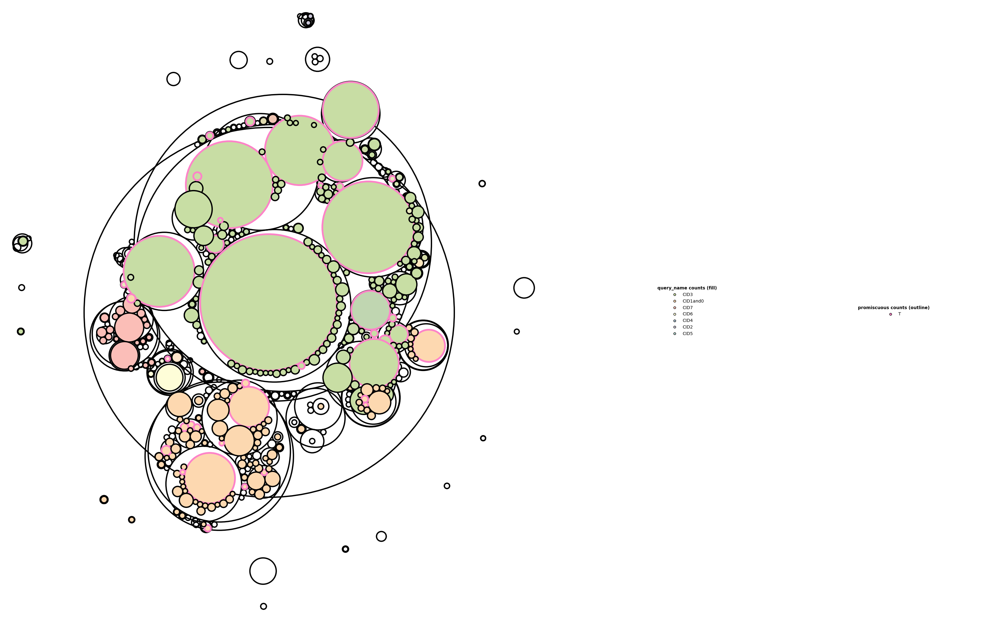

In [105]:
fig=cp.ExportFigure(layout, plot_data5, size=20)

In [106]:
fig.savefig('figures/mmseqs_IPscan_euk_promhk_raawpresenceabsence_cid.pdf', bbox_inches='tight')

## 3. Adding annotation tables  
When making the hierarchical cluster plot, we can add a data table that displays certain data for clusters.

We can re-use some of the data we've made.

First, the table we want to show (needs to have a "key" column that's used to ID the sequence). In this case we will use "Entry" as the key column.

In [61]:
annot_table.head() # table to display on click

,protein_accession,signature_accession_fingerprint,signature_spans,sequence_length_total,GH18_ID,signature_accession_fingerprint_GH18replaced,num_of_domains,no_GH18_domains
0,A0A010YG22,PS51910,PS51910[56-354],354,PS51910,GH18,1,1
1,A0A011PM39,PS51910 G3DSA:3.20.20.370 PF01522 PF13641,PS51910[133-455] G3DSA:3.20.20.370[503-716] PF...,1156,G3DSA:3.20.20.370 PS51910,GH18 GH18 PF01522 PF13641,4,2
2,A0A011PXQ4,PS51910 G3DSA:3.20.20.370 PF01522 PF13641,PS51910[133-444] G3DSA:3.20.20.370[504-716] PF...,1156,G3DSA:3.20.20.370 PS51910,GH18 GH18 PF01522 PF13641,4,2
3,A0A014LJM1,PS51910 PS51318,PS51910[56-344] PS51318[1-41],344,PS51910,GH18 PS51318,2,1
4,A0A014LR51,PS51910,PS51910[49-336],336,PS51910,GH18,1,1


Next, a mapping table that matches each ID ("Entry" in this case) to its corresponding cluster in each level.

In [90]:
clusters.head() # table for mapping each Entry to its level

,id,61.0,111.0,188.0,285.0,361.0,Uniprot_Accessions
0,0,0,0,3,7,5,A0A010Q896
1,1,0,0,3,7,5,A0A010QB65
2,10,0,0,0,22,104,A0A016S9Z0
3,100,0,1,1,5,8,A0A060SC99
4,1000,0,0,0,6,7,A0A0D2N077


Finally, we supply the table arguments to the circle plot function. Now clicking on the clusters fills the table with data. Note the data does not get compressed, and large tables (>10Mb) should be loaded at user's own discretion. It is best to label just what the user needs.

plot, plot_data1=cp.CirclePlot(layout, size=800, 
                              annot_text=[IPscan_GH18normfprint, IPscan_nodomains], annot_top_n=15, annot_na=False,
                              annot_colors=IPscan_GH18normfprintcolors)

                              annot_text=[IPscan_GH18fprint, IPscan_noGH18domains], annot_top_n=15, annot_na=False,
                              annot_colors=IPscan_GH18fprintcolors, outlines = IPscan_noGH18domainscolors, highlight_line_width = 2)

In [98]:
plot_table, plot_table_data = cp.CirclePlot(    layout,
                                                    annot_text=[IPscan_GH18fprint],
                                                    annot_colors = IPscan_GH18fprintcolors,
                                                    #outlines=reps_colors,
                                                    outlines = IPscan_noGH18domainscolors_bluesrev, highlight_line_width = 2,
                                                    # data table arguments
                                                    data_on_select_table=annot_table,
                                                    mapping_table=clusters,
                                                    data_key_column='protein_accession'
                                            )

## Saving as HTML

In addition to producing figures for publication, one can store an interactive version for later use or sharing. The HTML version can be opened in a browser (e.g., Chrome)

In [99]:
from bokeh.plotting import output_file, save

output_file('figures/mmseqs_IPscangh18dom_GH18domannot_bluesrevnoGH18doms_tab20c.html')
save(plot_table)

'/Users/sachapulsford/Library/CloudStorage/GoogleDrive-sachapulsford@gmail.com/My Drive/Jack_chitinases/250703/ProteinClusterTools/analyses/figures/mmseqs_IPscangh18dom_GH18domannot_bluesrevnoGH18doms_tab20c.html'